<a href="https://colab.research.google.com/github/PrathamBhat-prog/Deep-fake-detection/blob/main/Deepfake_Detection_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import pickle
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive, files
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from PIL import Image
import io

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
REAL_PATH = '/content/drive/MyDrive/real2'
FAKE_PATH = '/content/drive/MyDrive/fake2'

In [5]:
OUTPUT_PATH = '/content/drive/MyDrive/output'

In [6]:
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [7]:
def display_before_after(images_before, images_after, titles_before, titles_after, num_to_display=2):

    plt.figure(figsize=(10, 5 * num_to_display))
    for i in range(min(num_to_display, len(images_before))):
        # Before image
        plt.subplot(num_to_display, 2, 2*i+1)
        img = images_before[i]
        if img.max() <= 1.0:  # Denormalize if normalized
            img = (img * 255).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        plt.imshow(img)
        plt.title(titles_before[i])
        plt.axis('off')

        # After image
        plt.subplot(num_to_display, 2, 2*i+2)
        img = images_after[i]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(titles_after[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [8]:
def load_images(folder_path, label):
    images = []
    labels = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                images.append(img)
                labels.append(label)
            else:
                print(f"Warning: Could not load {img_path}")
    return images, labels
def display_images(images, titles, num_to_display=2):

    plt.figure(figsize=(10, 5))
    for i in range(min(num_to_display, len(images))):
        plt.subplot(1, num_to_display, i+1)
        img = images[i]
        if img.max() <= 1.0:  # Denormalize if normalized
            img = (img * 255).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display
        plt.imshow(img)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

In [9]:
def preprocess_image(img, target_size=(224, 224)):
    # Resize image
    img = cv2.resize(img, target_size)
    # Convert to RGB (in case of grayscale or other formats)
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        img = img[:, :, :3]
    # Apply Gaussian blur for noise reduction
    img = cv2.GaussianBlur(img, (3, 3), 0)
    # Normalize pixel values to [0,1]
    img = img / 255.0
    return img

In [10]:
def augment_images(images):
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    augmented_images = []
    for img in images:
        img = img.reshape((1,) + img.shape)  # Add batch dimension
        for batch in datagen.flow(img, batch_size=1):
            augmented_images.append(batch[0])
            break  # Generate one augmented image per original
    return np.array(augmented_images)

Loading real images...
Loaded 150 real images
Loading fake images...
Loaded 150 fake images
Preprocessing images...
Augmenting images...
Displaying augmented images...


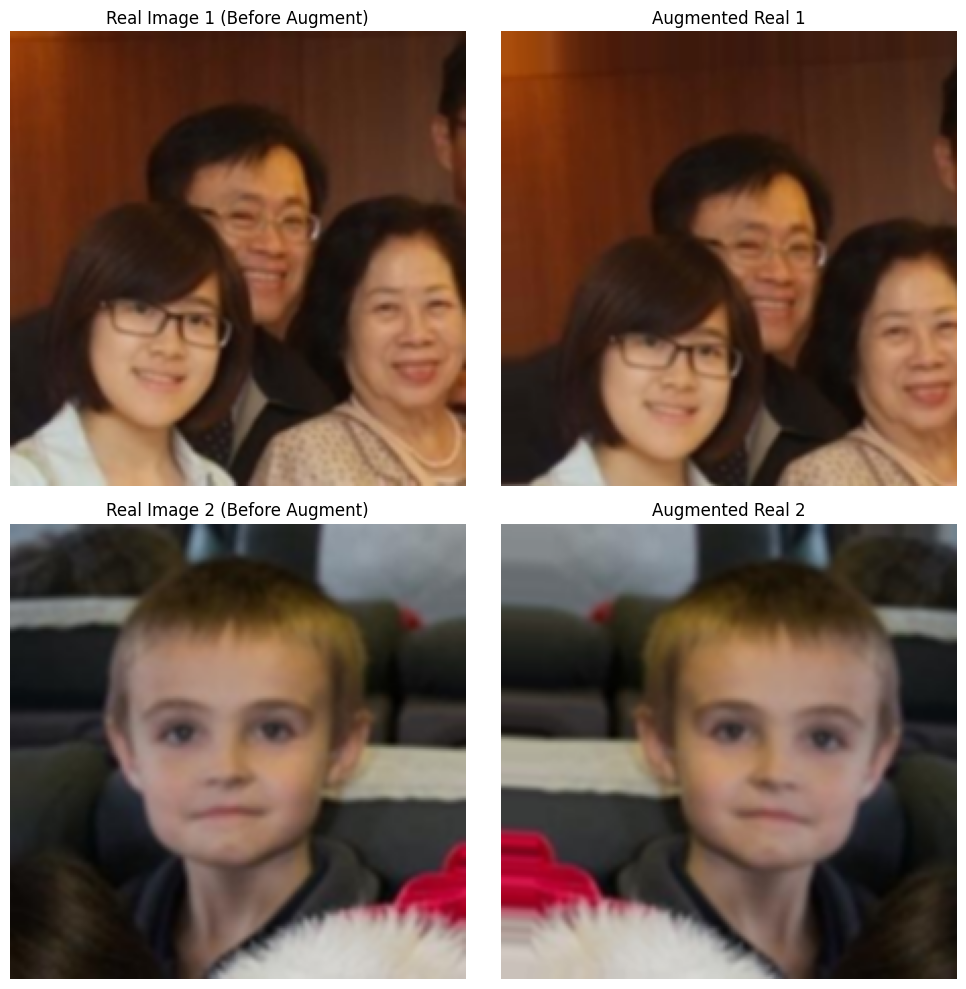

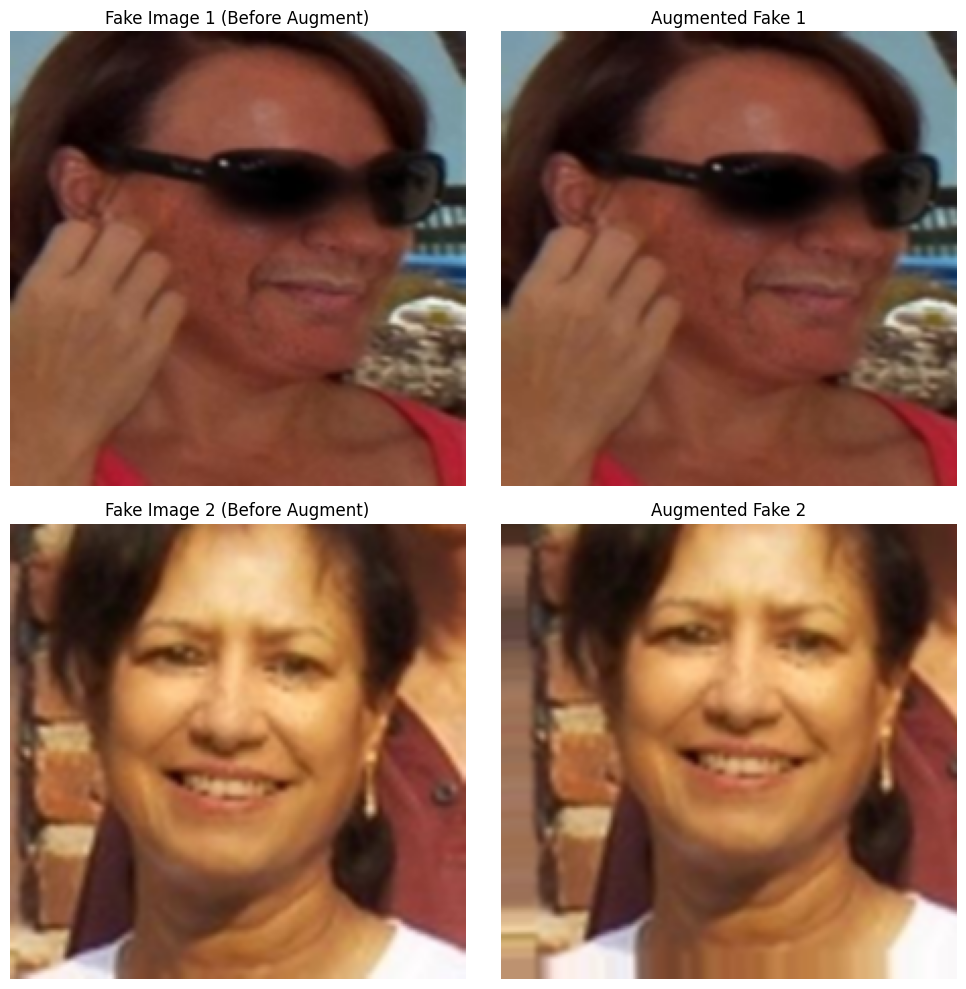

Total images after preprocessing and augmentation: 600
Preprocessed data saved to /content/drive/MyDrive/output/preprocessed_data.pkl


In [11]:
def preprocess_pipeline():
    # Load real and fake images
    print("Loading real images...")
    real_images, real_labels = load_images(REAL_PATH, 0)  # 0 for real
    print(f"Loaded {len(real_images)} real images")

    print("Loading fake images...")
    fake_images, fake_labels = load_images(FAKE_PATH, 1)  # 1 for fake
    print(f"Loaded {len(fake_images)} fake images")

    # Preprocess images
    print("Preprocessing images...")
    processed_real = [preprocess_image(img) for img in real_images]
    processed_fake = [preprocess_image(img) for img in fake_images]

    processed_real = np.array(processed_real)
    processed_fake = np.array(processed_fake)

    # Augment images
    print("Augmenting images...")
    augmented_real = augment_images(processed_real)
    augmented_fake = augment_images(processed_fake)

    # Display before and after augmentation
    print("Displaying augmented images...")
    if len(processed_real) > 0 and len(augmented_real) > 0:
        display_before_after(
            processed_real[:2], augmented_real[:2],
            ["Real Image 1 (Before Augment)", "Real Image 2 (Before Augment)"],
            ["Augmented Real 1", "Augmented Real 2"],
            num_to_display=2
        )
    if len(processed_fake) > 0 and len(augmented_fake) > 0:
        display_before_after(
            processed_fake[:2], augmented_fake[:2],
            ["Fake Image 1 (Before Augment)", "Fake Image 2 (Before Augment)"],
            ["Augmented Fake 1", "Augmented Fake 2"],
            num_to_display=2
        )

    # Combine datasets
    all_images = np.concatenate([processed_real, processed_fake, augmented_real, augmented_fake])
    all_labels = np.concatenate([
        real_labels,
        fake_labels,
        [0] * len(augmented_real),  # Labels for augmented real
        [1] * len(augmented_fake)   # Labels for augmented fake
    ])

    # Shuffle dataset
    indices = np.random.permutation(len(all_images))
    all_images = all_images[indices]
    all_labels = all_labels[indices]

    print(f"Total images after preprocessing and augmentation: {len(all_images)}")

    # Save preprocessed data
    output_file = os.path.join(OUTPUT_PATH, 'preprocessed_data.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump({'images': all_images, 'labels': all_labels}, f)
    print(f"Preprocessed data saved to {output_file}")

    return all_images, all_labels

# Run the pipeline
if __name__ == '__main__':
    preprocess_pipeline()

In [12]:
def load_preprocessed_data(input_path):

    try:
        with open(input_path, 'rb') as f:
            data = pickle.load(f)
        images = data['images']
        labels = data['labels']
        print(f"Loaded {len(images)} images with labels")
        return images, labels
    except Exception as e:
        print(f"Error loading preprocessed data: {e}")
        return None, None

In [13]:
def extract_vgg16_features(images):

    # Load VGG16 model without top layers
    model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Preprocess images for VGG16 (scale to [0, 255] and apply VGG-specific preprocessing)
    images = images * 255.0  # Denormalize from [0,1] to [0,255]
    images = preprocess_input(images)

    # Extract features
    features = model.predict(images, batch_size=32, verbose=1)

    # Flatten features (7x7x512 -> 25088 per image)
    features = features.reshape(features.shape[0], -1)

    # Reduce to ~2500 features (simple slicing for now, refined in MGO)
    target_dim = 2500
    features = features[:, :target_dim]

    print(f"Extracted features shape: {features.shape}")
    return features

In [14]:
def visualize_features(features, labels, num_to_display=2):

    real_indices = np.where(labels == 0)[0][:num_to_display]
    fake_indices = np.where(labels == 1)[0][:num_to_display]

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(real_indices):
        plt.subplot(2, num_to_display, i+1)
        feature = features[idx].reshape(50, 50)  # Reshape for visualization
        plt.imshow(feature, cmap='viridis')
        plt.title(f"Real Feature {i+1}")
        plt.axis('off')

    for i, idx in enumerate(fake_indices):
        plt.subplot(2, num_to_display, num_to_display+i+1)
        feature = features[idx].reshape(50, 50)  # Reshape for visualization
        plt.imshow(feature, cmap='viridis')
        plt.title(f"Fake Feature {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [15]:
INPUT_PATH = '/content/drive/MyDrive/output/preprocessed_data.pkl'
OUTPUT_PATH = '/content/drive/MyDrive/output'

In [16]:
import tensorflow as tf
try:
    from tensorflow.keras.applications import VGG16
    from tensorflow.keras.applications.vgg16 import preprocess_input
    print(f"TensorFlow version: {tf.__version__}")
    print("VGG16 and preprocess_input imported successfully")
except ImportError as e:
    print(f"Error importing VGG16 or preprocess_input: {e}")
    raise

TensorFlow version: 2.18.0
VGG16 and preprocess_input imported successfully


Loading preprocessed data from /content/drive/MyDrive/output/preprocessed_data.pkl
Loaded 600 images with labels
Extracting features with VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 603ms/step
Extracted features shape: (600, 2500)
Visualizing feature vectors...


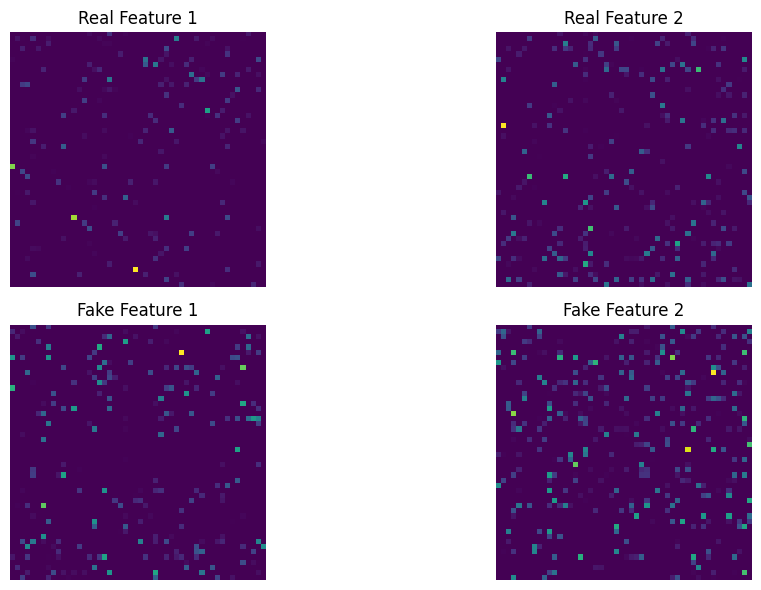

Features saved to /content/drive/MyDrive/output/extracted_features.pkl


In [17]:
def feature_extraction_pipeline():
    # Load preprocessed data
    print(f"Loading preprocessed data from {INPUT_PATH}")
    images, labels = load_preprocessed_data(INPUT_PATH)
    if images is None or labels is None:
        print("Aborting due to data loading error")
        return

    # Extract features
    print("Extracting features with VGG16...")
    features = extract_vgg16_features(images)

    # Visualize a few feature vectors
    print("Visualizing feature vectors...")
    visualize_features(features, labels, num_to_display=2)

    # Save features and labels
    output_file = os.path.join(OUTPUT_PATH, 'extracted_features.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump({'features': features, 'labels': labels}, f)
    print(f"Features saved to {output_file}")

    return features, labels

# Run the pipeline
if __name__ == '__main__':
    feature_extraction_pipeline()

In [18]:
INPUT_PATH = '/content/drive/MyDrive/output/extracted_features.pkl'  # Corrected path to extracted features
OUTPUT_PATH = '/content/drive/MyDrive/output'

In [19]:
def load_extracted_features(input_path):

    print(f"Loading features from {input_path}")
    try:
        with open(input_path, 'rb') as f:
            data = pickle.load(f)
        features = data['features']
        labels = data['labels']
        print(f"Loaded features shape: {features.shape}")
        return features, labels
    except Exception as e:
        print(f"Error loading extracted features: {e}")
        return None, None

In [20]:
def fitness_function(features, selected_indices, labels):

    selected_features = features[:, selected_indices == 1]
    if selected_features.shape[1] == 0:  # Avoid empty feature sets
        return 0.0
    clf = SVC(kernel='linear')
    scores = cross_val_score(clf, selected_features, labels, cv=3, scoring='accuracy')
    return np.mean(scores)

In [44]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import numpy as np
import matplotlib.pyplot as plt

# Define the default fitness function (using the simple neural network)
def default_fitness_function(features, selected_indices, labels):
    """
    Evaluates the fitness of a feature subset using a simple neural network
    with cross-validation. (Default)
    """
    selected_features = features[:, selected_indices == 1]
    if selected_features.shape[1] == 0:  # Avoid empty feature sets
        return 0.0

    # Build a simple neural network model for fitness evaluation
    model = Sequential([
        Input(shape=(selected_features.shape[1],)), # Use Input layer to specify shape
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Use StratifiedKFold for cross-validation to maintain class distribution
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    accuracies = []

    # Manually perform cross-validation training and evaluation
    for train_index, val_index in cv.split(selected_features, labels):
        X_train, X_val = selected_features[train_index], selected_features[val_index]
        y_train, y_val = labels[train_index], labels[val_index]

        # Train the model (with fewer epochs for faster evaluation)
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0) # Reduced epochs

        # Evaluate the model
        loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
        accuracies.append(accuracy)

    return np.mean(accuracies)


def modified_grasshopper_optimization(features, labels, num_features_to_select=500, num_grasshoppers=2, max_iterations=10, fitness_function=default_fitness_function): # Reduced max_iterations and num_grasshoppers

    num_features = features.shape[1]

    # Initialize grasshoppers (binary positions: 1 = select, 0 = discard)
    positions = np.random.randint(0, 2, size=(num_grasshoppers, num_features))
    for i in range(num_grasshoppers):
        # Ensure exactly num_features_to_select are selected
        selected = np.where(positions[i] == 1)[0]
        if len(selected) > num_features_to_select:
            positions[i, selected[:len(selected) - num_features_to_select]] = 0
        elif len(selected) < num_features_to_select:
            unselected = np.where(positions[i] == 0)[0]
            positions[i, unselected[:num_features_to_select - len(selected)]] = 1

    # Initialize best solution
    fitness_values = np.array([fitness_function(features, pos, labels) for pos in positions])
    best_idx = np.argmax(fitness_values)
    best_position = positions[best_idx].copy()
    best_fitness = fitness_values[best_idx]
    fitness_history = [best_fitness]

    # MGO parameters
    c_max, c_min = 2.0, 0.00001  # Parameter for controlling step size (Increased c_max)
    for iteration in range(max_iterations):
        # Adaptive c parameter (MGO modification)
        c = c_max - (c_max - c_min) * (iteration / max_iterations)

        # Update each grasshopper's position
        for i in range(num_grasshoppers):
            # Social interaction: attraction to best position and other grasshoppers
            attraction = np.zeros(num_features)
            for j in range(num_grasshoppers):
                if i != j:
                    distance = np.linalg.norm(positions[i] - positions[j])
                    if distance > 0:
                        attraction += (positions[i] - positions[j]) * np.exp(-distance / 2)

            # Update position (continuous, then binarize)
            r1, r2 = np.random.random(), np.random.random()
            new_position = best_position + r1 * c * attraction + r2 * (best_position - positions[i]) # Adjusted attraction scaling
            new_position = 1 / (1 + np.exp(-new_position))  # Sigmoid for binarization
            new_position = (new_position > 0.5).astype(int)

            # Ensure exactly num_features_to_select are selected
            selected = np.where(new_position == 1)[0]
            if len(selected) > num_features_to_select:
                new_position[selected[:len(selected) - num_features_to_select]] = 0
            elif len(selected) < num_features_to_select:
                unselected = np.where(new_position == 0)[0]
                np.random.shuffle(unselected)
                new_position[unselected[:num_features_to_select - len(selected)]] = 1

            positions[i] = new_position

        # Evaluate fitness
        fitness_values = np.array([fitness_function(features, pos, labels) for pos in positions])
        current_best_idx = np.argmax(fitness_values)
        current_best_fitness = fitness_values[current_best_idx]

        # Update global best
        if current_best_fitness > best_fitness:
            best_position = positions[current_best_idx].copy()
            best_fitness = current_best_fitness

        fitness_history.append(best_fitness)
        print(f"Iteration {iteration + 1}/{max_iterations}, Best Fitness: {best_fitness:.4f}")

    return best_position, best_fitness, fitness_history

In [22]:
def plot_fitness_history(fitness_history):

    plt.figure(figsize=(8, 5))
    plt.plot(fitness_history, marker='o')
    plt.title("MGO Fitness Progress (Classification Accuracy)")
    plt.xlabel("Iteration")
    plt.ylabel("Best Fitness (Accuracy)")
    plt.grid(True)
    plt.show()

In [23]:
def plot_selected_features(selected_indices):

    plt.figure(figsize=(12, 2))
    plt.imshow(selected_indices.reshape(1, -1), cmap='binary', aspect='auto')
    plt.title("Selected Features (1 = Selected, 0 = Discarded)")
    plt.xlabel("Feature Index")
    plt.yticks([])
    plt.colorbar(label="Selection (1/0)")
    plt.show()

In [24]:
def visualize_reduced_features(features, labels, num_to_display=2):

    real_indices = np.where(labels == 0)[0][:num_to_display]
    fake_indices = np.where(labels == 1)[0][:num_to_display]

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(real_indices):
        plt.subplot(2, num_to_display, i+1)
        feature = features[idx].reshape(25, 20)  # Reshape 500 features to 25x20
        plt.imshow(feature, cmap='viridis')
        plt.title(f"Real Reduced Feature {i+1}")
        plt.axis('off')

    for i, idx in enumerate(fake_indices):
        plt.subplot(2, num_to_display, num_to_display+i+1)
        feature = features[idx].reshape(25, 20)  # Reshape 500 features to 25x20
        plt.imshow(feature, cmap='viridis')
        plt.title(f"Fake Reduced Feature {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pickle
import os
import matplotlib.pyplot as plt

def load_selected_features(input_path):
    """
    Load selected features, labels, and selected indices from a pickle file.
    """
    print(f"Loading selected features from {input_path}")
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} does not exist")
        return None, None, None

    try:
        with open(input_path, 'rb') as f:
            data = pickle.load(f)

        if 'features' not in data or 'labels' not in data or 'selected_indices' not in data:
            print(f"Error: File {input_path} does not contain required keys")
            print("Keys found:", list(data.keys()))
            return None, None, None

        features = data['features']
        labels = data['labels']
        selected_indices = data['selected_indices']
        print(f"Loaded features shape: {features.shape}")
        print(f"Loaded labels shape: {labels.shape}")
        return features, labels, selected_indices
    except Exception as e:
        print(f"Error loading selected features: {e}")
        return None, None, None


# Load selected features
features, labels, selected_indices = load_selected_features(INPUT_PATH)

if features is not None and labels is not None:
    # Perform PCA for dimensionality reduction to 2 components
    print("Performing PCA for visualization...")
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features)

    # Perform t-SNE for dimensionality reduction to 2 components
    # t-SNE is computationally more expensive and sensitive to perplexity and iterations.
    # Using a smaller subset for t-SNE if the dataset is large can be faster.
    # For 600 samples, t-SNE should be manageable.
    print("Performing t-SNE for visualization...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
    features_tsne = tsne.fit_transform(features)

    # Visualize PCA results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.title('PCA of Features')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    legend = plt.legend(*scatter.legend_elements(), title="Labels")
    plt.grid(True)

    # Visualize t-SNE results
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.title('t-SNE of Features')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    legend = plt.legend(*scatter.legend_elements(), title="Labels")
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Could not load features for visualization.")

Loading selected features from /content/drive/MyDrive/output/extracted_features.pkl
Error: File /content/drive/MyDrive/output/extracted_features.pkl does not contain required keys
Keys found: ['features', 'labels']
Could not load features for visualization.


Starting MGO feature selection pipeline...
Loading features from /content/drive/MyDrive/output/extracted_features.pkl
Loaded features shape: (600, 2500)
Starting MGO feature selection...
Iteration 1/10, Best Fitness: 0.9600
Iteration 2/10, Best Fitness: 0.9600
Iteration 3/10, Best Fitness: 0.9600
Iteration 4/10, Best Fitness: 0.9600
Iteration 5/10, Best Fitness: 0.9600
Iteration 6/10, Best Fitness: 0.9600
Iteration 7/10, Best Fitness: 0.9600
Iteration 8/10, Best Fitness: 0.9600
Iteration 9/10, Best Fitness: 0.9600
Iteration 10/10, Best Fitness: 0.9600
Best fitness (accuracy) after MGO: 0.9600
Reduced features shape: (600, 500)
Visualizing MGO results...


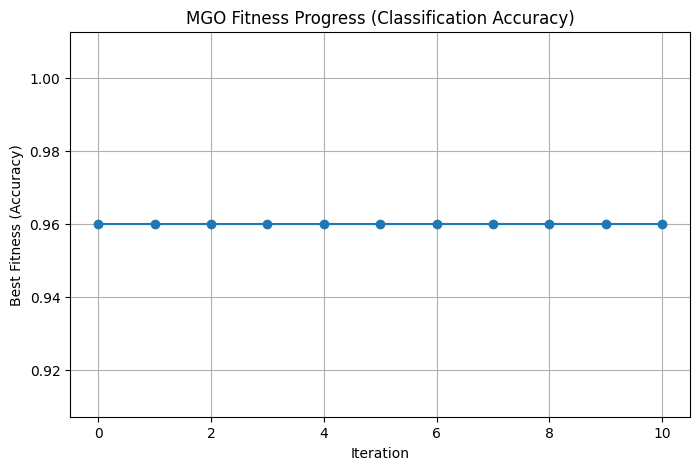

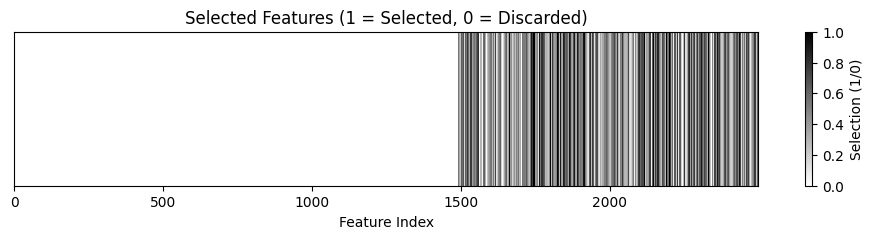

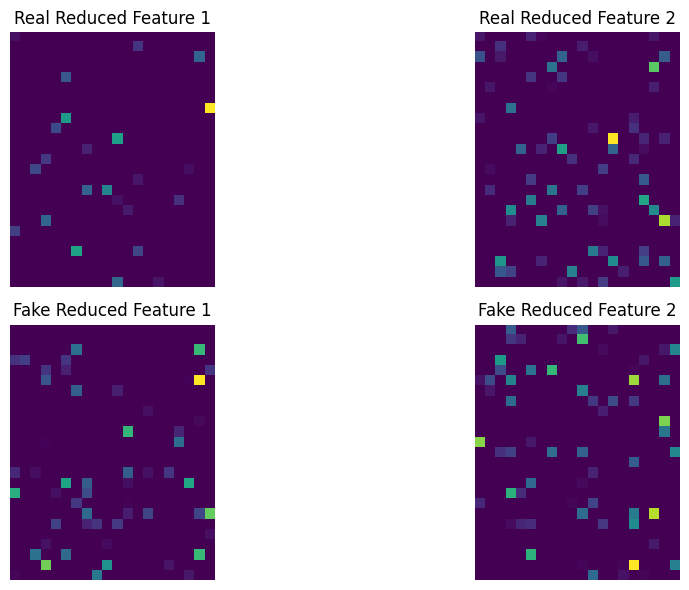

Saving selected features to /content/drive/MyDrive/output/selected_features.pkl
Selected features saved successfully


In [28]:
def mgo_feature_selection_pipeline():

    # Load extracted features
    features, labels = load_extracted_features(INPUT_PATH)
    if features is None or labels is None:
        print("Aborting due to data loading error")
        return

    # Perform MGO feature selection
    print("Starting MGO feature selection...")
    selected_indices, best_fitness, fitness_history = modified_grasshopper_optimization(
        features, labels, num_features_to_select=500, num_grasshoppers=2, max_iterations=10
    )
    print(f"Best fitness (accuracy) after MGO: {best_fitness:.4f}")

    # Apply feature selection
    selected_features = features[:, selected_indices == 1]
    print(f"Reduced features shape: {selected_features.shape}")

    # Visualize the MGO process
    print("Visualizing MGO results...")
    plot_fitness_history(fitness_history)
    plot_selected_features(selected_indices)
    visualize_reduced_features(selected_features, labels, num_to_display=2)

    # Save selected features and indices
    output_file = os.path.join(OUTPUT_PATH, 'selected_features.pkl')
    print(f"Saving selected features to {output_file}")
    with open(output_file, 'wb') as f:
        pickle.dump({
            'features': selected_features,
            'labels': labels,
            'selected_indices': selected_indices
        }, f)
    print("Selected features saved successfully")

# Run the pipeline
if __name__ == '__main__':
    print("Starting MGO feature selection pipeline...")
    mgo_feature_selection_pipeline()

In [29]:
INPUT_PATH = '/content/drive/MyDrive/output/selected_features.pkl'
OUTPUT_PATH = '/content/drive/MyDrive/output'

In [30]:
def load_selected_features(input_path):
    """
    Load selected features, labels, and selected indices from a pickle file.
    """
    print(f"Loading selected features from {input_path}")
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} does not exist")
        return None, None, None

    try:
        with open(input_path, 'rb') as f:
            data = pickle.load(f)

        if 'features' not in data or 'labels' not in data or 'selected_indices' not in data:
            print(f"Error: File {input_path} does not contain required keys")
            print("Keys found:", list(data.keys()))
            return None, None, None

        features = data['features']
        labels = data['labels']
        selected_indices = data['selected_indices']
        print(f"Loaded features shape: {features.shape}")
        print(f"Loaded labels shape: {labels.shape}")
        return features, labels, selected_indices
    except Exception as e:
        print(f"Error loading selected features: {e}")
        return None, None, None

In [31]:
def build_and_train_cnn(features, labels, epochs=20, batch_size=32):
    """
    Build and train a CNN classifier on the selected features.
    """
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

    # Reshape features for CNN (1D input: 500 features -> (500, 1))
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # Build the CNN model
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification (real/fake)
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {test_accuracy:.4f}")

    return model, history, X_test, y_test

In [32]:
def plot_training_history(history):

    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [33]:
def plot_confusion_matrix(model, X_test, y_test):

    y_pred = (model.predict(X_test) > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()


In [34]:
def process_new_image(image_path, selected_indices):
    """
    Preprocess a new image, extract VGG16 features, and apply MGO feature selection.
    """
    # Load and preprocess the image
    print("Preprocessing the uploaded image...")
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))  # Resize to VGG16 input size
    img_array = np.array(img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # VGG16 preprocessing

    # Extract VGG16 features
    print("Extracting VGG16 features...")
    vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    features = vgg_model.predict(img_array, verbose=0)
    features = features.reshape(features.shape[0], -1)  # Flatten
    features = features[:, :2500]  # Slice to 2500 features (same as training)
    print(f"Extracted features shape: {features.shape}")

    # Apply MGO feature selection
    selected_features = features[:, selected_indices == 1]
    print(f"Selected features shape: {selected_features.shape}")

    # Reshape for CNN
    selected_features = selected_features.reshape(selected_features.shape[0], selected_features.shape[1], 1)
    return selected_features

Starting CNN classification pipeline...
Loading selected features from /content/drive/MyDrive/output/selected_features.pkl
Loaded features shape: (600, 500)
Loaded labels shape: (600,)
Building and training the CNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 498, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 249, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 247, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 128)            │     1,007,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_116 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,209 (3.87 MB)

 Trainable params: 1,014,209 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.7274 - loss: 1.1246 - val_accuracy: 0.8333 - val_loss: 0.3950
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8393 - loss: 0.4152 - val_accuracy: 0.8417 - val_loss: 0.3543
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9100 - loss: 0.2431 - val_accuracy: 0.8667 - val_loss: 0.3006
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9518 - loss: 0.1641 - val_accuracy: 0.8750 - val_loss: 0.2739
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9728 - loss: 0.0884 - val_accuracy: 0.8833 - val_loss: 0.3000
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9873 - loss: 0.0583 - val_accuracy: 0.8750 - val_loss: 0.3077
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9733 - loss: 0.0592 - val_accuracy: 0.8833 - val_loss: 0.3481
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9764 - loss: 0.0525 - val_accuracy: 0.8833 - val

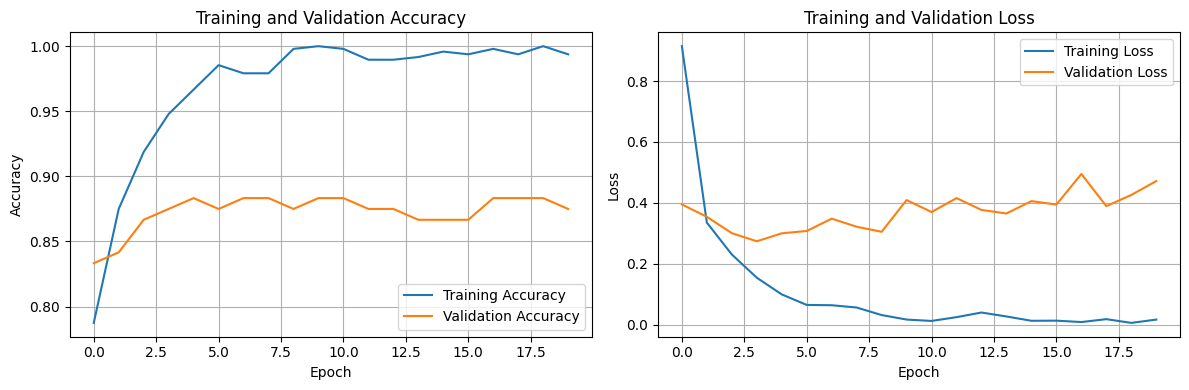

Visualizing confusion matrix...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


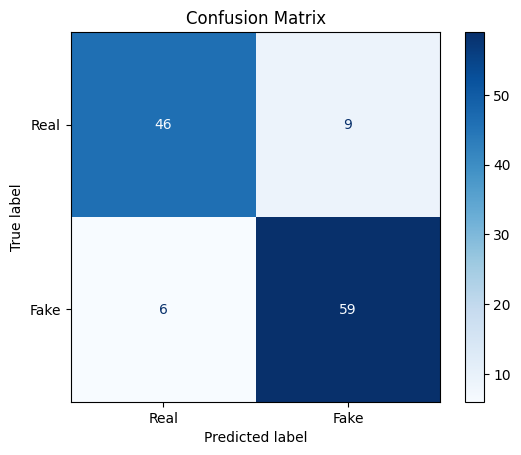

Model saved to /content/drive/MyDrive/output/cnn_model.h5

Upload a photo to predict if it's real or fake:


Saving WhatsApp Image 2025-05-15 at 1.44.16 PM.jpeg to WhatsApp Image 2025-05-15 at 1.44.16 PM.jpeg

Processing uploaded file: WhatsApp Image 2025-05-15 at 1.44.16 PM.jpeg
Preprocessing the uploaded image...
Extracting VGG16 features...


Extracted features shape: (1, 2500)
Selected features shape: (1, 500)
Predicting with the CNN...

Prediction Probabilities:
Real: 99.84%
Fake: 0.16%


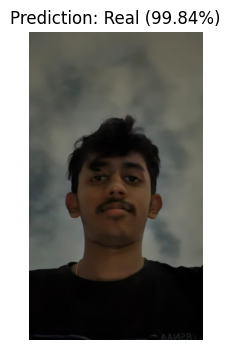

In [35]:
def cnn_classification_pipeline():
    """
    Main pipeline for CNN classification, evaluation, and photo prediction.
    """
    # Load selected features
    features, labels, selected_indices = load_selected_features(INPUT_PATH)
    if features is None or labels is None or selected_indices is None:
        print("Aborting due to data loading error")
        return

    # Build and train the CNN
    print("Building and training the CNN...")
    model, history, X_test, y_test = build_and_train_cnn(features, labels, epochs=20, batch_size=32)

    # Plot training history
    print("Visualizing training history...")
    plot_training_history(history)

    # Plot confusion matrix
    print("Visualizing confusion matrix...")
    plot_confusion_matrix(model, X_test, y_test)

    # Save the model
    model_path = os.path.join(OUTPUT_PATH, 'cnn_model.h5')
    model.save(model_path)
    print(f"Model saved to {model_path}")

    # Allow user to upload a new photo
    print("\nUpload a photo to predict if it's real or fake:")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded. Exiting.")
        return

    # Process the uploaded photo
    for filename in uploaded.keys():
        print(f"\nProcessing uploaded file: {filename}")
        new_features = process_new_image(io.BytesIO(uploaded[filename]), selected_indices)

        # Predict with the CNN
        print("Predicting with the CNN...")
        prediction = model.predict(new_features, verbose=0)[0][0]
        real_prob = (1 - prediction) * 100
        fake_prob = prediction * 100

        # Display the prediction
        print(f"\nPrediction Probabilities:")
        print(f"Real: {real_prob:.2f}%")
        print(f"Fake: {fake_prob:.2f}%")

        # Display the image
        img = Image.open(io.BytesIO(uploaded[filename]))
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Prediction: {'Fake' if fake_prob > 50 else 'Real'} ({max(real_prob, fake_prob):.2f}%)")
        plt.axis('off')
        plt.show()

# Run the pipeline
if __name__ == '__main__':
    print("Starting CNN classification pipeline...")
    cnn_classification_pipeline()

In [36]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_input_resnet

In [37]:
def extract_resnet50_features(images):
    """
    Extracts features from preprocessed images using ResNet50.
    """
    # Load ResNet50 model without top layers
    model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Preprocess images for ResNet50 (scale to [0, 255] and apply ResNet50-specific preprocessing)
    images = images * 255.0  # Denormalize from [0,1] to [0,255]
    images = preprocess_input_resnet(images)

    # Extract features
    features = model.predict(images, batch_size=32, verbose=1)

    # Flatten features
    features = features.reshape(features.shape[0], -1)

    print(f"Extracted ResNet50 features shape: {features.shape}")
    return features

In [38]:
def resnet50_feature_extraction_pipeline():
    """
    Pipeline for loading preprocessed data and extracting ResNet50 features.
    """
    # Load preprocessed data
    print(f"Loading preprocessed data from {INPUT_PATH}")
    # Assuming INPUT_PATH still points to the preprocessed_data.pkl from the first pipeline
    images, labels = load_preprocessed_data('/content/drive/MyDrive/output/preprocessed_data.pkl')
    if images is None or labels is None:
        print("Aborting due to data loading error")
        return

    # Extract features
    print("Extracting features with ResNet50...")
    features = extract_resnet50_features(images)

    # Visualize a few feature vectors (optional - might need adjustment for new feature shape)
    # print("Visualizing feature vectors...")
    # visualize_features(features, labels, num_to_display=2) # This visualization might not be meaningful for flattened ResNet50 features

    # Save features and labels
    output_file = os.path.join(OUTPUT_PATH, 'extracted_features_resnet50.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump({'features': features, 'labels': labels}, f)
    print(f"ResNet50 features saved to {output_file}")

    return features, labels

# You will need to call resnet50_feature_extraction_pipeline() to run this.

In [39]:
resnet50_feature_extraction_pipeline()

Loading preprocessed data from /content/drive/MyDrive/output/selected_features.pkl
Loaded 600 images with labels
Extracting features with ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 418ms/step
Extracted ResNet50 features shape: (600, 100352)
ResNet50 features saved to /content/drive/MyDrive/output/extracted_features_resnet50.pkl


(array([[0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , ..., 0.      , 8.671923, 0.      ],
        ...,
        [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , ..., 0.      , 5.663412, 0.      ]],
       dtype=float32),
 array([1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
        0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
        1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1

In [40]:
def mgo_feature_selection_pipeline_resnet50():
    """
    Pipeline for MGO feature selection using ResNet50 features.
    """
    # Load extracted ResNet50 features
    print(f"Loading ResNet50 features from {OUTPUT_PATH}/extracted_features_resnet50.pkl")
    features, labels = load_extracted_features(os.path.join(OUTPUT_PATH, 'extracted_features_resnet50.pkl'))
    if features is None or labels is None:
        print("Aborting due to data loading error")
        return

    # Perform MGO feature selection (using the default fitness function - Neural Network)
    print("Starting MGO feature selection with ResNet50 features...")
    selected_indices, best_fitness, fitness_history = modified_grasshopper_optimization(
        features, labels, num_features_to_select=500, num_grasshoppers=50, max_iterations=100,
        fitness_function=default_fitness_function # Use the default fitness function (Neural Network)
    )
    print(f"Best fitness (accuracy) after MGO with ResNet50 features: {best_fitness:.4f}")

    # Apply feature selection
    selected_features = features[:, selected_indices == 1]
    print(f"Reduced ResNet50 features shape: {selected_features.shape}")

    # Visualize the MGO process
    print("Visualizing MGO results...")
    plot_fitness_history(fitness_history)
    plot_selected_features(selected_indices)
    # Note: visualize_reduced_features might need adjustment for ResNet50 feature shape (100352 -> 500)
    # The current visualize_reduced_features is set up for VGG16 reduced features (2500 -> 500)
    # We can skip this visualization for now or create a new one if needed.
    # visualize_reduced_features(selected_features, labels, num_to_display=2)


    # Save selected features and indices
    # Save with a different name to distinguish from VGG16 selected features
    output_file = os.path.join(OUTPUT_PATH, 'selected_features_resnet50_mgo.pkl')
    print(f"Saving selected ResNet50 features to {output_file}")
    with open(output_file, 'wb') as f:
        pickle.dump({
            'features': selected_features,
            'labels': labels,
            'selected_indices': selected_indices
        }, f)
    print("Selected ResNet50 features saved successfully")

# This pipeline does not automatically run. You need to call mgo_feature_selection_pipeline_resnet50() to execute it.